# Data exploration and loading 💫

In [41]:
dataset_dir = "C:/Users/hP/Desktop/Datasets/train_ready_skeleton"

# CNN

In [42]:
from tensorflow.keras import layers, models
import tensorflow as tf
img_size = (64, 64)
batch_size = 2048
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,   # split training set into 80/20
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

Found 66272 files belonging to 29 classes.
Using 53018 files for training.
Found 66272 files belonging to 29 classes.
Using 13254 files for validation.


## Defining the CNN

In [43]:
model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(64,64,3)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(29, activation='softmax')
])


In [44]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


## Train

In [45]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 336s 13s/step - accuracy: 0.1518 - loss: 15.1811 - val_accuracy: 0.4939 - val_loss: 1.9613
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 291s 11s/step - accuracy: 0.7238 - loss: 0.9743 - val_accuracy: 0.9087 - val_loss: 0.3538
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 309s 12s/step - accuracy: 0.9390 - loss: 0.2420 - val_accuracy: 0.9573 - val_loss: 0.1695
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 318s 12s/step - accuracy: 0.9708 - loss: 0.1247 - val_accuracy: 0.9744 - val_loss: 0.1117
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 330s 13s/step - accuracy: 0.9827 - loss: 0.0766 - val_accuracy: 0.9818 - val_loss: 0.0809
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 309s 12s/step - accuracy: 0.9890 - loss: 0.0492 - val_accuracy: 0.9858 - val_loss: 0.0694
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 313s 12s/step - accuracy: 0.9929 - loss: 0.0321 - val_accuracy: 0.9878 - val_loss: 0.0592
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 307s 12s/step - accuracy: 0.9958 - loss: 0.0191 - val_accuracy: 0

## Evaluate

In [46]:
loss, acc = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {acc:.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9892 - loss: 0.0570
Validation Loss: 0.0570
Validation Accuracy: 0.9892


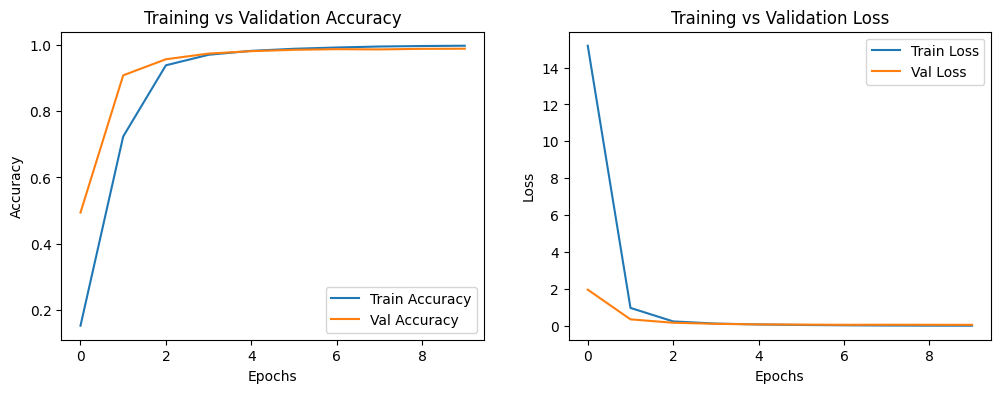

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")

plt.show()


In [48]:
#Saving the model as .h5
model.save("cnn_model.h5")

## Applying the model on the 28 test images

In [49]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
])


In [53]:
import mediapipe as mp
import cv2
import numpy as np
import uuid
import os
mp_drawing = mp.solutions.drawing_utils
mp_hands = mp.solutions.hands
def load_and_preprocess_with_label(img):
    img = cv2.resize(img, img_size)
    img = img.astype('float32') / 255.0  # normalize
    img = np.expand_dims(img, axis=0)    # add batch dimension
    return img
cap = cv2.VideoCapture(0)
with mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.3) as hands: 
    while cap.isOpened():
        ret, frame = cap.read()
        
        # BGR 2 RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Flip on horizontal
        h, w = image.shape[:2]
        if h < 200 or w < 200:
            scale_factor = max(200 / h, 200 / w)
            new_w = int(w * scale_factor)
            new_h = int(h * scale_factor)
            image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
        
        # Set flag
        image.flags.writeable = False
        
        # Detections
        results = hands.process(image)
        
        # Set flag to true
        image.flags.writeable = True
        
        # RGB 2 BGR
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        # Detections
        print(results)
        

        if results.multi_hand_landmarks:
            for num, hand in enumerate(results.multi_hand_landmarks):
                mp_drawing.draw_landmarks(image, hand, mp_hands.HAND_CONNECTIONS, 
                                        mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=2, circle_radius=3),
                                        mp_drawing.DrawingSpec(color=(0, 0, 255), thickness=2),
                                         )
            
        cv2.imshow('Hand Tracking', image)
        y_test_pred = model.predict(load_and_preprocess_with_label(image))
        y_test_pred_classes = y_test_pred.argmax(axis=1)
        print(y_test_pred_classes)
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    

cap.release()
cv2.destroyAllWindows()



<class 'mediapipe.python.solution_base.SolutionOutputs'>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[8]
<class 'mediapipe.python.solution_base.SolutionOutputs'>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[8]
<class 'mediapipe.python.solution_base.SolutionOutputs'>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[8]
<class 'mediapipe.python.solution_base.SolutionOutputs'>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[8]
<class 'mediapipe.python.solution_base.SolutionOutputs'>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[8]
<class 'mediapipe.python.solution_base.SolutionOutputs'>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[8]
<class 'mediapipe.python.solution_base.SolutionOutputs'>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[8]
<class 'mediapipe.python.solution_base.SolutionOutputs'>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[8]
<class 'mediapipe.python.solution_base.SolutionOutputs'>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
[8]
<class 'mediapipe.python.solution_base.SolutionOutputs'>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[8]
<class 'me

KeyboardInterrupt: 

In [ ]:
import numpy as np

# Map labels to integers
unique_labels = sorted(set(test_labels))
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

y_test_true = np.array([label_to_index[label] for label in test_labels])

print("Label mapping:", label_to_index)
print("True labels shape:", y_test_true.shape)


Label mapping: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'nothing': 26, 'space': 27}
True labels shape: (28,)


In [ ]:
import tensorflow as tf

def load_and_preprocess_with_label(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    return img, label

# Build dataset
test_ds = tf.data.Dataset.from_tensor_slices((test_image_paths, y_test_true))
test_ds = test_ds.map(load_and_preprocess_with_label, num_parallel_calls=AUTOTUNE)

# Apply your preprocessing
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE).batch(batch_size)


In [ ]:
y_test_pred = model.predict(test_ds)
y_test_pred_classes = y_test_pred.argmax(axis=1)

from sklearn.metrics import accuracy_score, classification_report

print("Test Accuracy:", accuracy_score(y_test_true, y_test_pred_classes))
print("\nClassification Report:\n", classification_report(y_test_true, y_test_pred_classes))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
Test Accuracy: 0.8928571428571429

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test_true, y_test_pred_classes)
print(f"Accuracy: {acc:.2%}")
print(f"Correct predictions: {int(acc * len(y_test_true))}/{len(y_test_true)}")


Accuracy: 89.29%
Correct predictions: 25/28
